<a href="https://colab.research.google.com/github/zamoralinokevin-eng/Maestria-en-IA/blob/main/Zamora_Kevin_EDA_predictivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad: análisis exploratorio de datos para analítica predictiva
## Caso: suscripción a un depósito a plazo tras una llamada de telemarketing bancario

Programación para Analítica Descriptiva y Predictiva · Tema : EDA con Analítica Predictiva
Maestría en Inteligencia Artificial y Analítica de Datos · UACJ

**Nombre del estudiante:** Kevin Josue Zamora Lino  

**Matrícula:** 271753

**Fecha:** 2026-10-09

## Propósito

Aplicar, de forma individual y sobre un conjunto de datos nuevo, el procedimiento de análisis exploratorio para analítica predictiva revisado en el notebook guiado del caso Telco. El producto de la actividad es una **hoja de decisiones** de preprocesamiento y modelado, sustentada en evidencia obtenida con el código.

No se entrena ningún modelo en esta actividad.

## Instrucciones de entrega

1. Completa las celdas de código y las de texto marcadas con **Tu predicción**, **Tu observación** o **Tu respuesta**.
2. Antes de entregar, ejecuta el notebook completo con *Kernel > Restart & Run All*. El notebook debe ejecutarse de principio a fin sin errores.
3. Guarda el archivo como `Apellido_Nombre_EDA_predictivo.ipynb` y entrégalo en el medio indicado por el profesor.
4. La actividad es individual. Las predicciones deben escribirse **antes** de ejecutar cada celda de código.

## Reglas de trabajo

- Usa solo el conjunto `df` y las librerías ya importadas.
- Después de la división de la parte C, el conjunto `prueba` **no se utiliza** en ninguna celda.
- Usa `random_state=42` en toda operación aleatoria, para que los resultados sean comparables.
- Las observaciones y las decisiones citan cifras obtenidas con tu propio código.

## Conjunto de datos y fuente

**Bank Marketing** (archivo `bank-additional-full.csv`), del repositorio UCI de aprendizaje automático. Cada fila es un contacto telefónico de una campaña de marketing directo de un banco portugués. El conjunto contiene 41,188 contactos ordenados por fecha, de mayo de 2008 a noviembre de 2010, y 21 columnas.


**Problema predictivo.** Clasificación binaria: dadas las características de un cliente y del contexto de la campaña, predecir si el cliente contratará el depósito a plazo (`y`).

**Diccionario de datos**

| Columna | Contenido |
| --- | --- |
| `age` | Edad del cliente |
| `job`, `marital`, `education` | Ocupación, estado civil y escolaridad |
| `default`, `housing`, `loan` | Si tiene crédito en incumplimiento, crédito hipotecario y préstamo personal |
| `contact` | Medio de contacto: `cellular` o `telephone` |
| `month`, `day_of_week` | Mes y día de la semana del último contacto de la campaña actual |
| `duration` | Duración de la última llamada, en segundos |
| `campaign` | Número de contactos con este cliente en la campaña actual, incluido el último |
| `pdays` | Días transcurridos desde el último contacto de una campaña anterior; `999` indica que no fue contactado antes |
| `previous` | Número de contactos antes de la campaña actual |
| `poutcome` | Resultado de la campaña anterior: `success`, `failure` o `nonexistent` |
| `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed` | Indicadores económicos trimestrales o mensuales: variación del empleo, índice de precios, índice de confianza del consumidor, tasa Euribor a 3 meses y número de empleados |
| `y` | Variable objetivo: `yes` si el cliente contrató el depósito, `no` si no |

## 1. Preparación del entorno y carga de datos (celda proporcionada)

Ejecuta la celda sin modificarla. Si el archivo no está en la carpeta, la celda lo descarga de una copia pública del conjunto; si ya está, lo reutiliza. El archivo usa punto y coma como separador.

In [51]:
import os
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
AZUL = "#1E2761"
NARANJA = "#D98E04"
COLORES_CLASE = {"no": AZUL, "yes": NARANJA}
pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 120)

url = "https://raw.githubusercontent.com/selva86/datasets/master/bank-additional-full.csv"
archivo = "bank_marketing.csv"

if not os.path.exists(archivo):
    urllib.request.urlretrieve(url, archivo)

df = pd.read_csv(archivo, sep=";")

numericas = ["age", "duration", "campaign", "pdays", "previous",
             "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
categoricas = ["job", "marital", "education", "default", "housing", "loan",
               "contact", "month", "day_of_week", "poutcome"]
macro = ["emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

print("Filas y columnas:", df.shape)

Filas y columnas: (41188, 21)


## Parte A. Definición del problema

**Por qué.** Un EDA predictivo se orienta por preguntas que se responden antes de calcular nada. Una de ellas, qué información estará disponible al momento de predecir, decide qué variables pueden entrar al modelo.

Completa la columna **Respuesta** de la siguiente tabla, editando esta celda.

| Pregunta | Respuesta |
| --- | --- |
| ¿Qué es una observación? | Es un registro de un contacto telefónico realizado a un cliente durante una campaña de marketing directo de un banco portugués. |
| ¿Qué se predice? | Predecir si el cliente contratará o no un depósito a plazo "y" |
| ¿Qué tipo de problema es? | Clasificación Binaria |
| ¿En qué momento se haría la predicción y qué información existiría entonces?  | La predicción se realiza antes de hacer la llamada en la campaña de marketing. La información que existiría es el historial financiero como préstamos, datos del cliente. Tambien resultados de campañas previas. |
| ¿Qué columnas no deberían usarse como características y por qué? | La columna objetivo ""y" no debe usarse.La duracion de la llamada tampoco debe usarse porque registra el tiempo después de que la llamada finaliza. El incluirla puede causar fuga de datos.  |

**Tu predicción.** ¿Qué porcentaje de los contactos esperas que haya terminado en contratación del depósito? Espero que el porcentaje de los contactos que hayan terminado en contratación del depósito sea bajo porque las personas cada vez aceptan menos llamadas telefónicas de números desconocidos y menos de los bancos o de marketing por temor a fraude.

## Parte B. Descripción de los datos y detección de problemas de calidad, conjunto total

**Por qué.** La descripción (tamaño, tipos, significado de las columnas) y la detección de problemas con criterios estructurales o del dominio no usan la variable objetivo ni calculan parámetros que se aplicarán al modelo. Por eso se hacen con el conjunto total `df`, antes de dividir. Esta parte **detecta y cuantifica**; las decisiones de tratamiento se toman en la hoja de la parte G.

Las verificaciones de calidad de CRISP-DM que se piden son: consistencia de valores, cantidad y distribución de valores nulos, y valores fuera de rango.

**Pista.** En este conjunto los faltantes en variables categóricas se codifican con el texto `unknown`, no con `NaN`.

**Tu predicción.** ¿Habrá valores `NaN`? ¿En qué columnas esperas encontrar `unknown` y en cuántas filas? Escribe tu respuesta aquí, antes de ejecutar la celda de código. Espero que no hayan valores Nan ya que en la pista previa, se menciona que estos fueron reemplazados por el texto "unknown", También los datasets del repositorio UCI de aprendizaje automático ya suele venir con preprocesamiento. Espero eentontrar esta palabra en las variables categóricas como: marital, job, education y contact porque las personas a veces no suelen dar su información personal. La cantidad de filas en las que se puede encontrar esto estaría entre el 5 y 15%.

In [52]:
# B1. Estructura.

#  - las dimensiones del conjunto,
print(f"Las dimensiones del conjunto son: {df.shape[0]} filas y {df.shape[1]} columnas.\n")

#  - el tipo de dato de cada columna
print(f"El tipo de dato de cada columna es \n{df.dtypes}")

#  - el número de valores únicos por columna, de menor a mayor.
print(f"\nEl número de valores únicos por columna es:\n{df.nunique().sort_values(ascending=False)}")

Las dimensiones del conjunto son: 41188 filas y 21 columnas.

El tipo de dato de cada columna es 
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

El número de valores únicos por columna es:
duration          1544
euribor3m          316
age                 78
campaign            42
pdays               27
cons.price.idx      26
cons.conf.idx       26
job                 12
nr.employed         11
emp.var.rate        10
month               10
education            8
previous             

In [53]:
# B2. Valores faltantes.
#  - el total de valores NaN del conjunto,
print(f"El total de valores NaN del conjunto es: {df.isna().sum().sum()}")

#  - para las columnas categóricas, cuántas filas tienen "unknown" (solo las columnas con al menos una)
categoricas_unknown = (df[categoricas]=="unknown").sum().sort_values(ascending=False)

#  - ese conteo como porcentaje de las filas.
categoricas_pct = round((df[categoricas]=="unknown").mean()*100,2)

unknown_df = pd.DataFrame({"Conteo": categoricas_unknown,
                           "Porcentaje": categoricas_pct})
print(f"\nLas columnas categóricas con unknown mayor a 0 son:\n{unknown_df[unknown_df["Conteo"] >0]}")

El total de valores NaN del conjunto es: 0

Las columnas categóricas con unknown mayor a 0 son:
           Conteo  Porcentaje
default      8597       20.87
education    1731        4.20
housing       990        2.40
job           330        0.80
loan          990        2.40
marital        80        0.19


In [54]:
# B3. Duplicados.
print(f"Las filas completamente idénticas son: {df.duplicated().sum()}")

Las filas completamente idénticas son: 12


In [55]:
# B4. Consistencia entre columnas relacionadas.
#  - cuántas filas tienen pdays igual a 999 y qué porcentaje es,
conteo_pdays = (df["pdays"]==999).sum()
pct_pdays = (df["pdays"]==999).mean()*100
print(f"Las filas con pdays igual a 999 son {conteo_pdays} y el porcentaje es {pct_pdays:.2f}%")

#  - una tabla de contingencia entre poutcome y (previous == 0)
print("\nLa tabla de contingencia entre poutcome y previous == 0 es:")
print(pd.crosstab(df["poutcome"], df["previous"]==0))

#  - una tabla de contingencia entre poutcome y (pdays == 999).
print("\nLa tabla de contingencia entre poutcome y pdays == 999 es:")
print(pd.crosstab(df["poutcome"], df["pdays"]==999))

Las filas con pdays igual a 999 son 39673 y el porcentaje es 96.32%

La tabla de contingencia entre poutcome y previous == 0 es:
previous     False  True 
poutcome                 
failure       4252      0
nonexistent      0  35563
success       1373      0

La tabla de contingencia entre poutcome y pdays == 999 es:
pdays        False  True 
poutcome                 
failure        142   4110
nonexistent      0  35563
success       1373      0


In [56]:
# B5. Rangos según el dominio.
#  - la edad mínima y máxima
print(f"La edad mínima es {df["age"].min()} y la edad máxima es {df["age"].max()}")

#  - cuántas llamadas tienen duration igual a 0
print(f"\nLas llamadas con duration igual a 0 son: {(df["duration"]==0).sum()}")

#  - el mínimo y el máximo de campaign,
print(f"\nEl mínimo de campaign es {df["campaign"].min()} y el máximo es {df["campaign"].max()}")

#  - cuántas filas tienen previous negativo.
print(f"\nLas filas con previous negativo son {(df["previous"]<0).sum()}")

La edad mínima es 17 y la edad máxima es 98

Las llamadas con duration igual a 0 son: 4

El mínimo de campaign es 1 y el máximo es 56

Las filas con previous negativo son 0


**Tu observación.** Se calculó el tamaño del dataset y muestra 41188 filas y 21 columnas. Se evaluó la cantidad de valores NaN y no se encotnró ninguno. En vez de esto, se evaluó el valor unknown en las variables categóricas, encontrándose en 6 de este tipo. La variable categórica de mas valores fue "default" con el 20.87%.
En la consistencia entre columnas relacionadas, se aprecia que el porcentaje de filas con "pdays" igual a 999 es de 96.32% de los datos. En la variable "poutcome" con "previous" igual a cero y "pdays" igual a 999, se observó que la categoría "nonexistent" tiene los 35563 valores como verdaderos. La edad está en un rango entre 17 y 98 años lo que se puede considerar normal y dependiente del significado de la variable. Se encontraron 4 llamadas con duración igual a cero por lo que este valor también depende del significado de la variable.


**Tu respuesta.** ¿Qué harías con `unknown` en `default`: tratarla como una categoría más, imputarla o eliminar las filas? Para la variable "default" encontrar la categoría "unknown" es considerada hasta ahora como otra categoría mas debido a la cantidad enorme de datos que tienen este valor (8597 valores). No se recomienda eliminar las filas con esta categoría porque se perdería en 20.87% de los datos. Tampoco se recomienda imputar con la moda, porque es una variable categórica y el hacerlo puede sesgar los datos.

## Parte C. División en entrenamiento y prueba

**Por qué.** La exploración que sigue relaciona características con la variable objetivo y fundamenta decisiones de modelado. Si usara los datos de prueba, esas decisiones incorporarían información de los datos con los que después se evaluará el modelo (fuga de información). Por eso se aparta el conjunto de prueba y no se vuelve a tocar hasta la evaluación final.

**Especificaciones.**

- 80% entrenamiento y 20% prueba.
- División estratificada según `y`.
- `random_state=42`.
- Guarda los conjuntos como `entrenamiento` y `prueba`.
- Crea `ent`, una copia de `entrenamiento`, y agrega a `ent` la columna `suscribe` con 1 si `y` es `yes` y 0 si es `no`.

**Tu predicción.** ¿La proporción de contratación será igual en entrenamiento y prueba? ¿Por qué? La proporcion de contratación en entrenamiento y prueba deben ser igual ya que la variable objetivo será distribuida en partes iguales en el conjunto de entrenamiento y de prueba. Esta distribución simétrica es para asegurar que no exista fuga de información.

In [57]:
# C1. Escribe el código de la división y la creación de ent y de la columna suscribe.
entrenamiento, prueba = train_test_split(df, test_size=0.2, stratify=df["y"], random_state=42)

#se crea ent como una copia de entrenamiento y la columna suscribe
ent = entrenamiento.copy()
ent["suscribe"] = (ent["y"]=="yes").astype(int)

# se imprime:
#  - el tamaño de entrenamiento y de prueba
print(f"El tamaño del conjunto de entrenamiento es: {entrenamiento.shape[0]}")
print(f"El tamaño del conjunto de prueba es {prueba.shape[0]}")

#
#  - el porcentaje de contratación (y igual a yes) en cada uno.
print(f"\nEl porcentaje de contratación en entrenamiento es {(entrenamiento["y"]=="yes").mean()*100:.2f}%")
print(f"El porcentaje de contratación en prueba es {(prueba["y"]=="yes").mean()*100:.2f}%")

El tamaño del conjunto de entrenamiento es: 32950
El tamaño del conjunto de prueba es 8238

El porcentaje de contratación en entrenamiento es 11.27%
El porcentaje de contratación en prueba es 11.26%


**Verificación (celda proporcionada).** Ejecútala para comprobar que la división coincide con las especificaciones. Si muestra que no se superó, revisa `test_size`, `stratify` y `random_state`.


In [58]:
if entrenamiento.shape[0] == 32950 and prueba.shape[0] == 8238 and "suscribe" in ent.columns and abs(ent["suscribe"].mean() - 0.1127) < 0.0005:
    print("Verificación superada.")
else:
    print("Verificación no superada: revisa la división y la columna suscribe.")

Verificación superada.


**Tu observación.** Compara las dos proporciones con tu predicción. Escribe tu respuesta aquí y compárala con tu predicción.
Las dos porporciones coinciden con la predicción, con una pequeña diferencia de 0.01% en la proporción entre ambas. La verificación arrojó el mensaje de "Verificación superada" por lo que se acepta como válida la estratificación de los datos.

**A partir de aquí el conjunto `prueba` no se usa.** Todo el análisis trabaja sobre `ent`.

## Parte D. Exploración del objetivo y de las variables numéricas, entrenamiento

### D1. Variable objetivo

**Por qué.** En clasificación, la distribución de la variable objetivo condiciona las métricas de evaluación, la validación y la necesidad de rebalancear. Es lo primero que se examina.

**Tu predicción.** Si un modelo respondiera siempre `no`, ¿qué exactitud obtendría? Escribe tu respuesta aquí, antes de ejecutar la celda de código.
Si un modelo respondiera siempre No, este obtendría una exactitud del 88% ya que es la diferencia encontrada con el cálculo anterior (porcentaje de contratación de 11.27%)

El número de clientes en cada clase es:
y
no     29238
yes     3712
Name: count, dtype: int64

El porcentaje de clientes en cada clase es:
y
no     88.73
yes    11.27
Name: proportion, dtype: float64

La razón entre la clase mayoritaria y la minoritaria es: 7.88

La exactitud de responder siempre no es 88.73%



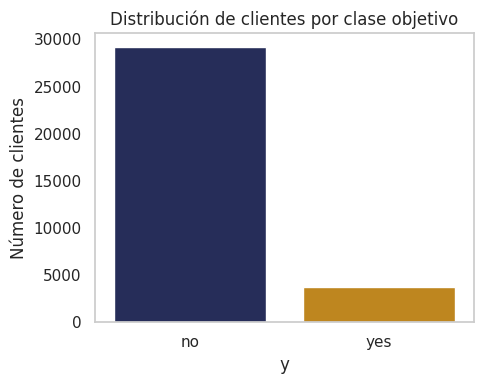

In [59]:
# D1. Escribe el código que muestre:
#  - el número y el porcentaje de clientes de cada clase en ent,
conteos = ent["y"].value_counts()
porcentajes = round(ent["y"].value_counts(normalize=True)*100,2)
print(f"El número de clientes en cada clase es:\n{conteos}")
print(f"\nEl porcentaje de clientes en cada clase es:\n{porcentajes}")


#  - la razón entre la clase mayoritaria y la minoritaria
#la clase mayoritaria es "no"
razon_no = conteos["no"] / conteos["yes"]
print(f"\nLa razón entre la clase mayoritaria y la minoritaria es: {razon_no:.2f}")

#  - la exactitud de responder siempre "no"
exactitud_no = porcentajes["no"]

print(f"\nLa exactitud de responder siempre no es {exactitud_no:.2f}%\n")

#  - una gráfica de barras con el número de clientes por clase.
plt.figure(figsize=(5,4))
sns.barplot(x=conteos.index,
            y=conteos.values,
            hue=conteos.index,
            palette=COLORES_CLASE,
            legend=False)
plt.grid(False)
plt.title("Distribución de clientes por clase objetivo")
plt.ylabel("Número de clientes")
plt.tight_layout()
plt.show()

**Tu observación.** Compara con tu predicción de las partes A y D y explica qué implica para la evaluación del modelo. Escribe tu respuesta aquí y compárala con tu predicción.
En el dataset "ent", la variable objetivo "y" presenta 29238 valores de  "no" (88.73%) y 3712 valores de "si" (11.27%). La razon entre no/si es de 7.88, siendo "no" la clase mayoritaria. Esta razon de 7.88:1 muestra un severo desbalance de clases. Si se crea un modelo que prediga el "no", éste tendrá una exactitud del 88.73% por lo que esta métrica no es útil para evaluar el problema

### D2. Variables numéricas según la clase

**Por qué.** Para cada característica numérica interesa cómo se distribuye en cada clase: si lo hace de forma distinta, la variable separa a quienes contratan de quienes no. Se compara la mediana porque es resistente a valores extremos.

**Tu predicción.** ¿Cuáles de las variables numéricas esperas que más difieran entre quienes contratan y quienes no? Escribe tu respuesta aquí, antes de ejecutar la celda de código. Mi predicción es que las variables numéricas que mas difieren entre las personas que contratan el servicio son: "pdays" porque muestra el éxito en dias tras haber contratado un cliente. "euribor3m" puede ser util tambien por la tasa de interés que es fijada en los bancos que determina en gran parte las personas que deciden contratar el servicio.

La mediana de cada variable numérica por clase de y es:
y                     no       yes
age               38.000    37.000
duration         164.000   448.000
campaign           2.000     2.000
pdays            999.000   999.000
previous           0.000     0.000
emp.var.rate       1.100    -1.800
cons.price.idx    93.918    93.200
cons.conf.idx    -41.800   -40.400
euribor3m          4.857     1.266
nr.employed     5195.800  5099.100



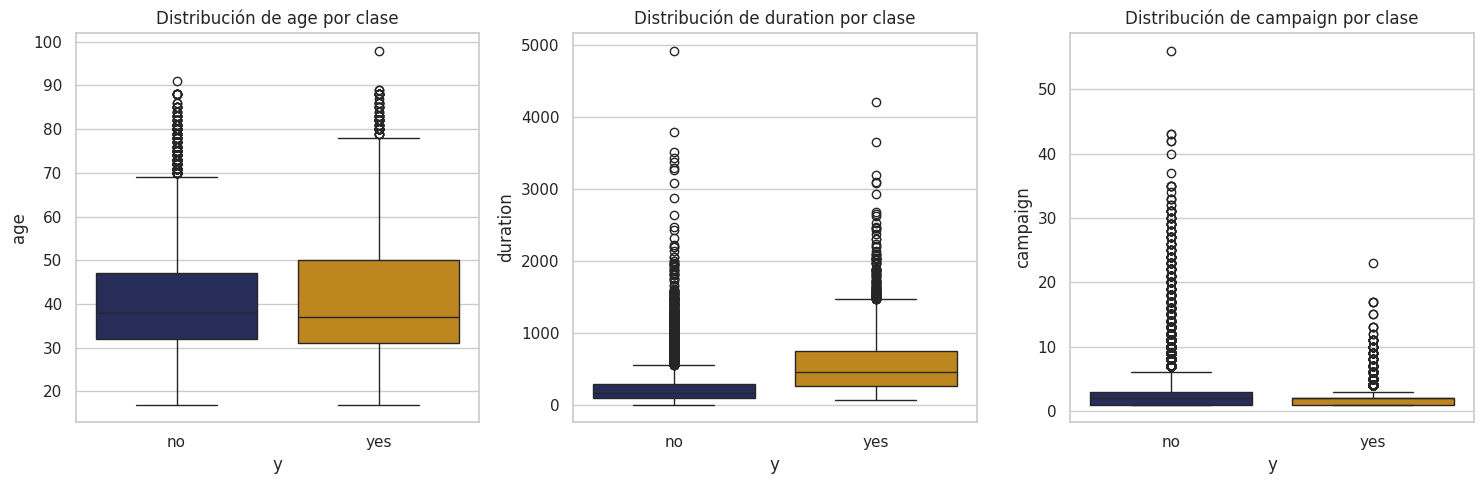

In [60]:
# D2. Escribe el código que muestre:
#  - la mediana de cada variable numérica (lista numericas) por clase
mediana_numerica = ent.groupby("y")[numericas].median().T
print(f"La mediana de cada variable numérica por clase de y es:\n{mediana_numerica}\n")

#  - diagramas de caja por clase de y de al menos tres variables numéricas que elijas.
variables_numericas = ["age", "duration", "campaign"]

fig, axes = plt.subplots(1, 3, figsize=(15,5))

#se crean los diagramas de caja en cada iteración
for ax, var in zip(axes, variables_numericas):
  sns.boxplot(data=ent, x="y", y=var, hue="y", ax=ax, palette=COLORES_CLASE)
  ax.set_title(f"Distribución de {var} por clase")
plt.tight_layout()
plt.show()


**Tu observación.** Indica qué variables separan las clases y cuáles no, con las medianas. Escribe tu respuesta aquí y compárala con tu predicción.
Las variables que presentan mas notoria la separación por la mediana son: duration con 164 de "yes" y 448 de "no", euribor3m con 4.857 de "yes" y 1.266 de "no", nr.employed con 5195.8 d "yes" y 5099.1 de "no". Las variables que no se separan con las clases son: campaign con 2.0 en "yes" y "no", pdays con 999 en "yes" y "no", previous con 0 em ambas. Refernete a mi predicción, tuvo una correcta con euribor3m pero con pdays no fue certera.

### D3. Valores atípicos

**Por qué.** Los modelos lineales, las máquinas de soporte vectorial y las redes neuronales son sensibles a valores extremos y a la escala; los árboles de decisión y sus conjuntos no lo son. El EDA documenta el problema y la decisión depende del modelo.

Los límites de Tukey (1.5 veces el rango intercuartílico) se calculan con los cuartiles de los datos, por lo que se obtienen con el conjunto de entrenamiento.

**Tu predicción.** ¿Qué variables numéricas esperas que tengan más registros fuera de los límites de Tukey? Escribe tu respuesta aquí, antes de ejecutar la celda de código. Las variables que espero que tengan más registros fuera de los límites de Tukey son campaign (inistencia a un mismo cliente), age (personas muy mayores de edad) y duration. El diagrama de caja previamente graficado muestra la presencia de estos outliers arriba del bigote superior.

In [61]:
# D3. Escribe el código que calcule, con ent, los límites inferior y superior de Tukey
outliers_tukey = {}
for var in numericas:
  q3 = ent[var].quantile(0.75)
  q1 = ent[var].quantile(0.25)
  iqr = q3 - q1
  lim_sup = q3 + 1.5 * iqr
  lim_inf = q1 - 1.5 * iqr
  fuera = ((ent[var]< lim_inf)|(ent[var]>lim_sup)).sum()
  outliers_tukey[var] = [lim_inf, lim_sup, fuera]

# de cada variable de la lista numericas y muestre cuántos registros quedan fuera de ellos por variable.
outliers_df = pd.DataFrame.from_dict(outliers_tukey, orient='index', columns=['Lim Inferior', 'Lim Superior', 'Registros Fuera'])
print(outliers_df)

                Lim Inferior  Lim Superior  Registros Fuera
age                   9.5000       69.5000              368
duration           -221.0000      643.0000             2366
campaign             -2.0000        6.0000             1916
pdays               999.0000      999.0000             1226
previous              0.0000        0.0000             4534
emp.var.rate         -6.6000        6.2000                0
cons.price.idx       91.6965       95.3725                0
cons.conf.idx       -52.1500      -26.9500              359
euribor3m            -4.0815       10.3865                0
nr.employed        4905.6000     5421.6000                0


**Tu respuesta.** ¿Eliminarías los registros atípicos de alguna variable? Justifica por variable con lo que sabes de su significado. Escribe tu respuesta aquí. Tendría que evaluar cada variable para saber si el valor atípico debe ser eliminado. En caso de age, el límite superior es 69.5 años por lo que valores atípicos representan adultos quw pueden contratar el servicio. En campaign, los atípicos representan la persistencia de la campaña como parte del proceso. Pdays deben evaluarse los atípicos porque ambos límites son 999 que representan valores no registrados. con previous es probable que aplique el mismo caso que pdays solo que en vez de 999, se registraron con 0 la mayoría de valores que no se pudieron capturar.

### D4. Asimetría y re-expresión

**Por qué.** Cuando una variable tiene asimetría fuerte, una transformación monótona (raíz cuadrada o logaritmo) puede acercar su distribución a una forma simétrica. Un modelo sensible a la escala se beneficia; uno basado en árboles no. La asimetría guía la decisión.

**Tu predicción.** ¿Cuál transformación, raíz cuadrada o logaritmo (`np.log1p`), reducirá más la asimetría de `campaign`? Escribe tu respuesta aquí, antes de ejecutar la celda de código. La transformación de logaritmo reduciría mejor la asimetría de campaign debido a que esta variable tiene un sessgo con colas largas hacia la derecha donde la transformación de logaritmo es más eficiente que la raíz cuadrada.

Comparativa de las asimetrías.
          Original  Raíz Cuadrada  Logaritmo
age           0.76           0.43       0.13
duration      3.33           1.20      -0.43
campaign      4.74           2.16       1.35


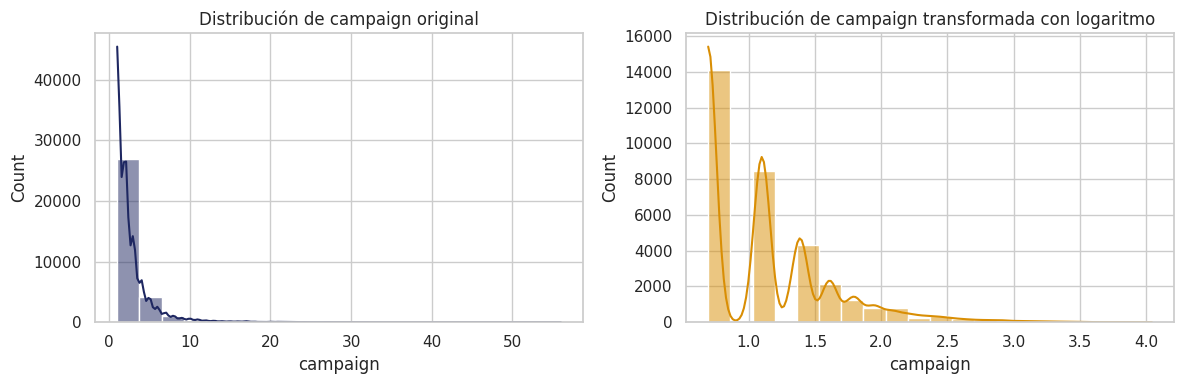

In [62]:
# D4. Escribe el código que muestre una tabla con la asimetría original, con raíz cuadrada y con
# logaritmo (np.log1p) de las variables age, duration y campaign, calculada con ent.
asimetrias = {}
for var in ["age", "duration", "campaign"]:
  original = ent[var].skew().round(2)
  raiz_cuadrada = np.sqrt(ent[var]).skew().round(2)
  logaritmo = np.log1p(ent[var]).skew().round(2)
  asimetrias[var] = [original, raiz_cuadrada, logaritmo]

#se crea el dataframe con los valores calculados
asimetrias_df = pd.DataFrame.from_dict(asimetrias, orient='index', columns=['Original', 'Raíz Cuadrada', 'Logaritmo'])
print(f"Comparativa de las asimetrías.\n{asimetrias_df}")

# Después grafica los histogramas de campaign: original y transformada.
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.histplot(ent["campaign"],kde=True, ax=axes[0], color=AZUL, bins=20)
axes[0].set_title("Distribución de campaign original")
sns.histplot(np.log1p(ent["campaign"]), kde=True, ax=axes[1], color=NARANJA, bins=20)
axes[1].set_title("Distribución de campaign transformada con logaritmo")
plt.tight_layout()
plt.show()

**Tu observación.** Reporta las asimetrías y decide qué transformación, si alguna, aplicarías a cada variable. Escribe tu respuesta aquí y compárala con tu predicción.
Las asimetrías son las siguientes: age con 0.76, duration con 3.33 y campaign con 4.74. Para age aplicaría la logarítmica porque se reduce a 0.13, para duration puedo aplicar la de la raíz cuadrada y la de campaign aplicaría la logarítmica para reducir la asimetría a 1.35

## Parte E. Exploración de las variables categóricas, entrenamiento

**Por qué.** Para una característica categórica, la medida natural es la **tasa de contratación por categoría** comparada con la tasa global, junto con el número de clientes: una tasa calculada con pocos registros es poco confiable.

**Tu predicción.** ¿Qué variable categórica esperas que tenga las categorías con mayor tasa de contratación? ¿Y cuáles esperas que casi no separen las clases? Escribe tu respuesta aquí, antes de ejecutar la celda de código.
La variable poutcome puede mostar una tasa de conversión mas alta si presentó el valor de "success". La variavle day_of_week no mostrará una gran diferencia.

In [63]:
# E1. Escribe el código que muestre:
#  - el número de categorías de cada variable de la lista categoricas,
print(f"Número de categorías por variable:\n{ent[categoricas].nunique()}")

#  - la tasa global de contratación en ent.
tasa_global = ent["suscribe"].mean()*100
print(f"\nTasa global de contratación en entrenamiento: {tasa_global:.2f}%")

Número de categorías por variable:
job            12
marital         4
education       8
default         3
housing         3
loan            3
contact         2
month          10
day_of_week     5
poutcome        3
dtype: int64

Tasa global de contratación en entrenamiento: 11.27%


In [64]:
# E2. Escribe el código que construya una tabla con el número de clientes y la tasa de contratación (en %)
# de cada categoría de cada variable de categoricas. Muestra:
lista_tablas = []

for col in categoricas:
  res_col = ent.groupby(col).agg(
      Clientes=("suscribe", "count"),
      Tasa_Contratacion=("suscribe", lambda x: round(x.mean()*100,2))
  ).reset_index().rename(columns={col:"Categoria"})
  res_col["Variable"] = col
  lista_tablas.append(res_col)

df_categorias = pd.concat(lista_tablas, ignore_index=True)[['Variable', 'Categoria', 'Clientes', 'Tasa_Contratacion']]

#  - las 12 categorías con mayor tasa
print(f"\nLas 12 categorías con mayor tasa de contratación son:\n{df_categorias.sort_values('Tasa_Contratacion', ascending=False).head(12)}")

#  - las 8 con menor tasa
print(f"\nLas 8 categorías con menor tasa de contratación son:\n{df_categorias.sort_values('Tasa_Contratacion', ascending=True).head(8)}")

#  - las tablas de default, housing, loan y day_of_week.
print("\n\nLas tablas de default, housing, loan y day_of_week son:")
for v in ["default", "housing", "loan", "day_of_week"]:
  print(f"\nVariable: {v}")
  print(df_categorias[df_categorias["Variable"]==v])
# Pista: reutiliza el patrón melt + groupby + agg del notebook guiado del caso Telco.


Las 12 categorías con mayor tasa de contratación son:
     Variable   Categoria  Clientes  Tasa_Contratacion
52   poutcome     success      1105              64.89
37      month         dec       143              50.35
40      month         mar       436              49.77
44      month         sep       464              44.61
43      month         oct       587              43.27
8         job     student       711              30.52
5         job     retired      1366              25.48
35      month         apr      2085              20.48
20  education  illiterate        16              18.75
15    marital     unknown        65              16.92
23  education     unknown      1397              14.82
33    contact    cellular     20908              14.70

Las 8 categorías con menor tasa de contratación son:
     Variable    Categoria  Clientes  Tasa_Contratacion
26    default          yes         3               0.00
25    default      unknown      6940               5.20
34    co

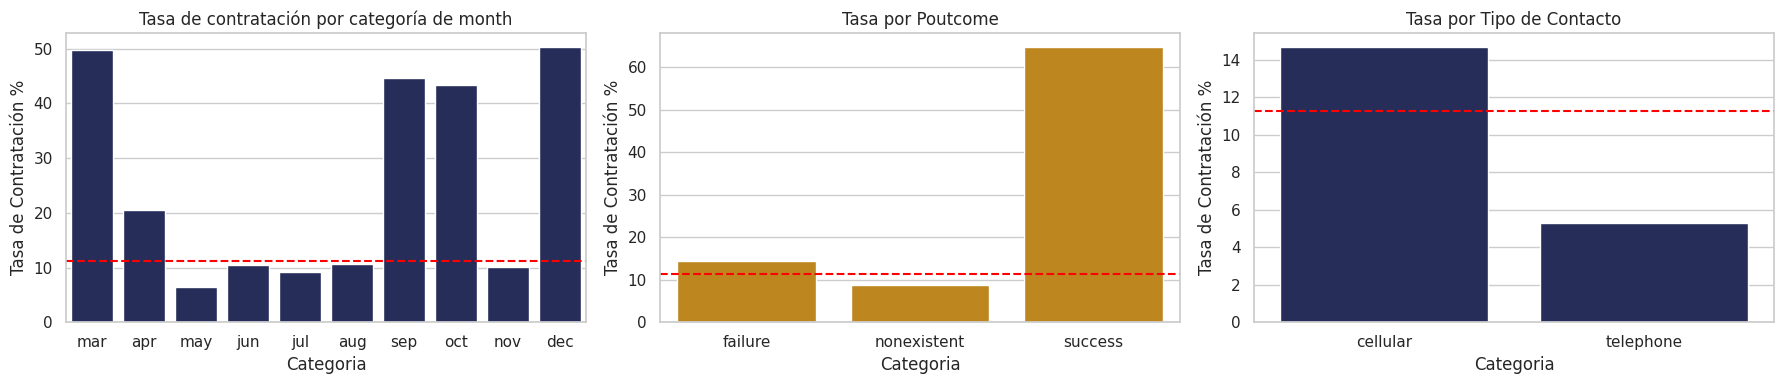

In [65]:
# E3. Escribe el código que grafique la tasa de contratación por categoría de month (en orden
# cronológico: mar, apr, may, jun, jul, aug, sep, oct, nov, dec), poutcome y contact,
# con una línea horizontal en la tasa global.
fig, axes = plt.subplots(1,3, figsize=(18,4))

#month
orden_meses = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
df_month = df_categorias[df_categorias["Variable"]=="month"].set_index("Categoria").reindex(orden_meses).reset_index()
sns.barplot(data=df_month, x="Categoria", y="Tasa_Contratacion", ax=axes[0], color=AZUL)
axes[0].set_title("Tasa de contratación por categoría de month")

#Poutcome
df_pout = df_categorias[df_categorias['Variable'] == 'poutcome']
sns.barplot(data=df_pout, x='Categoria', y='Tasa_Contratacion', ax=axes[1], color=NARANJA)
axes[1].set_title("Tasa por Poutcome")

#Contact
df_cont = df_categorias[df_categorias['Variable'] == 'contact']
sns.barplot(data=df_cont, x='Categoria', y='Tasa_Contratacion', ax=axes[2], color=AZUL)
axes[2].set_title("Tasa por Tipo de Contacto")

for ax in axes:
    ax.axhline(tasa_global, color='red', linestyle='--', label=f'Global ({tasa_global:.2f}%)')
    ax.set_ylabel("Tasa de Contratación %")
plt.tight_layout()
plt.show()


**Tu observación.** Identifica las categorías con mayor y menor tasa, con su tasa y su número de clientes, y las variables que casi no separan las clases. Escribe tu respuesta aquí y compárala con tu predicción.
La categoría con mayor tasa de éxito es success de poutcome con 1105 clientes y 64.89% de conversión. Luego vienen los meses de dec, mar y sep de la variable month con valores de 50.35%, 49.77% y 44.61% respectivamente, aunque con volúmenes más bajo de clientes. La categoría yes de la variable default presenta 0.0% de tasa de contratación con solo 3 clientes, may de month presenta sólo 6.35% de contratación pero un volumen de clientes de 11011. Las variables day_of_week, loan, housing tiene tasas que van desde el 10.25% hasta el 12.0% por lo que estas variables tienen muy poca capacidad para separar las clases.


**Tu respuesta.** En `default`, ¿qué indica que la categoría `unknown` tenga una tasa de contratación distinta a la de `no`? ¿Qué hay que cuidar con las categorías `yes` de `default` o `illiterate` de `education`? Escribe tu respuesta aquí.
Con la variable default, la categoría unknown con la tasa de 5.2% indica que no se conoce el estado de credito de los clientes por lo que se relaciona con una menor tasa de contratación por lo que puede seguir siendo una etiqueta autónoma. Con la variable default, la categoría de yes y con education y su categoria de illiterate hay que tener precaución ya que estos datos vienen de muestras muy bajas de la población (3 y 16 clientes) porque pueden ocasionar overfitting.

## Parte F. Relaciones entre características y variable `duration`, entrenamiento

### F1. Relaciones entre características

**Por qué.** Dos características muy relacionadas son redundantes y pueden causar inestabilidad en modelos lineales (colinealidad).

**Tu predicción.** ¿Qué pares de indicadores económicos (lista `macro`) esperas que estén más correlacionados? Escribe tu respuesta aquí, antes de ejecutar la celda de código.
Los pares de indicadores euribor3m y nr.employed son los que espero que estén mas correlacionados porque ambos se relacionan con el desarrollo económico  y laboral.

Matriz de correlación de variables económicas:
                emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed
emp.var.rate        1.000000        0.773923       0.195488   0.972154     0.906313
cons.price.idx      0.773923        1.000000       0.057918   0.686048     0.518472
cons.conf.idx       0.195488        0.057918       1.000000   0.277257     0.100555
euribor3m           0.972154        0.686048       0.277257   1.000000     0.944974
nr.employed         0.906313        0.518472       0.100555   0.944974     1.000000



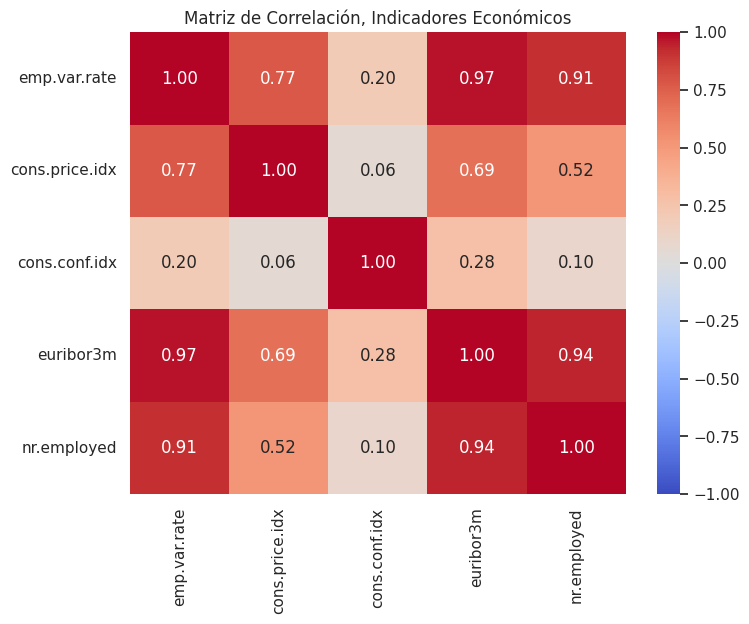

In [66]:
# F1. Escribe el código que muestre un mapa de calor con la matriz de correlación de las variables de la lista macro,
# calculada con ent, con los valores anotados en cada celda.
plt.figure(figsize=(8, 6))
#se crea el mapa de calor
sns.heatmap(ent[macro].corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)

#se imprime la matriz de correlación
print("Matriz de correlación de variables económicas:")
print(ent[macro].corr())
print()

#se muestra el mapa de calor
plt.title("Matriz de Correlación, Indicadores Económicos")
plt.show()

**Tu observación.** Reporta los pares más correlacionados y la decisión que implican. Escribe tu respuesta aquí y compárala con tu predicción.
Los pares más relacionados son los siguientes:
Euribor3m y emp.var.rate con una correlación de 0.97. nr.employed y euribor3m con una correlación de 0.94.
El incluir estas características redundantes en un modelo lineal puede generar inestabilidad en la estimación de coeficientes. Lo ideal es eliminar las variables que tengan correlació destructiva y dejar una que las represente, como en el caso de euribor3m.

### F2. La variable `duration`

**Por qué.** Una variable puede tener una relación muy fuerte con el objetivo y aun así no ser utilizable. Esto ocurre cuando su valor solo se conoce después del evento que se quiere predecir.

In [67]:
# F2. Escribe el código que muestre el resumen estadístico (describe) de duration por clase de y.
print("Estadísticas de duration por clase objetivo:")
print(ent.groupby('y')['duration'].describe().T)

Estadísticas de duration por clase objetivo:
y                no          yes
count  29238.000000  3712.000000
mean     221.148198   549.398976
std      208.303557   397.490060
min        0.000000    63.000000
25%       95.000000   252.000000
50%      164.000000   448.000000
75%      279.000000   737.000000
max     4918.000000  4199.000000


**Tu respuesta.** ¿Incluirías `duration` como característica de un modelo que se usará para decidir a quién llamar? Justifica con la definición de la variable y con lo observado. Escribe tu respuesta aquí.
No incluiría la variable duration como característica de un modelo para decidir a quien llamar. Aunque traiga una separacíon entre las medias de 221.14 para no y 549.39 para yes, este conteo se da sólo cuando finaliza el evento de contacto con el cliente y no serviría para las llamadas con antelación como en los modelos predictivos. Si utilizo esta variable, puedo causar fuga de datos.


**Tu respuesta.** El conjunto está ordenado por fecha y los indicadores económicos varían con el tiempo. ¿Qué implica dividir al azar, como en la parte C, para un modelo que se usará en campañas futuras? Escribe tu respuesta aquí.
Una division al azar puede ocasionar sesgo en los datos debido a la fuga de información. Para un entorno donde el pasado prediga el futuro, se debe usar unadivision temporal estructurada con los datos de tiempo mas recientes.

## Parte G. Hoja de decisiones y justificación del uso de los datos

### G1. Hoja de decisiones

**Por qué.** El producto de un EDA predictivo es una lista de decisiones, cada una con su evidencia. Ninguna decisión se aplica todavía sobre los datos.

Completa la tabla con **al menos siete decisiones**, cada una con un hallazgo de tu análisis (con su cifra), la decisión y el tema del curso donde se aplicaría (preprocesamiento, modelos, evaluación). Debe aparecer al menos una decisión sobre cada uno de estos aspectos: variable no utilizable, valores faltantes o códigos especiales, desbalance de clases, redundancia entre características y asimetría.

Edita esta celda y agrega las filas que necesites.

| Hallazgo (con cifra) | Decisión | Se aplica en |
| --- | --- | --- |
| La variable default con categoría unknown tiene 6940 clientes| Mantener la categoría porque a pesar de sólo represntar el 5.2% de contratación, la cantidad de clientes es alta | Preprocesamiento y COdificación |
| La categoría duration solo se cuantifica despues de la llamda telefónica (media de 549.39) | Eliminar la variable duration para prevenir fuga de datos | Preprocesamiento |
| Correlación entre variables muy alta, 0.97 entre euribor3m y emp.var.rate | Elimianr emp.var.rate y nr.employed, dejando s+olo euribor3m | Preprocesamiento |
| La variable "y" objetivo presenta fuerte desbalance de clases, de 7.88:1 con 11.2% de ocnversión positiva | Rechazar el uso de accuracy como métrica, usar técnicas de balanceo | Evaluación y selección de modelos |
| Categorías con muy pocos registros como default-yes-3 registros y education-illiterate-14 registros | Agrupar las categorías de baja frecuencia bajo el nombre "Otros | Preprocesamiento |
| Variable campaign con sesgo y cola larga hacia la derecha, asiemtría de 4.74 | Aplicar transformación logarítmica | Preprocesamiento y transformación |
| Variables como day_of_week, housing, loan muestran tasas de contratación bajos 10-12% | Considerar excluir las variables en etapa de optimización | Selección de características. |

### G2. Uso de los datos

**Tu respuesta.** En esta actividad, ¿qué partes se hicieron con el conjunto total y cuáles solo con entrenamiento? Explica el criterio. Escribe tu respuesta aquí.
La descripción conteo inicial de valores desconocidos, nulos, cálculo de duplicados se realizaron sobre el conjunto total. el ccriterio fue que estas funciones no afectan el EDA predictivo y atiende mas a la calidad de la estructura.
La exploración de relaciones entre variables, el cálculo de los límites de Tukey, análisis de asimetría, correlación entre variables se hicieron con el subconjunto ent sin considerar el conjunto de prueba, esto para evitar fuga de información y conversar una distribución de la variable objetivo sin modificar y para usarse posteriormente.

**Tu respuesta.** Si hubieras explorado también el conjunto de prueba, ¿qué decisión de tu hoja podría quedar sesgada y cómo se reflejaría en la evaluación final? Escribe tu respuesta aquí.
Al usar también el subconjunto de prueba, se hubieran modificado los límites de Tukey, o creado valores de correlación mas altos entre variables o inclusive usando información que el modelo predictivo no debe saber. Esta fuga de datos, sesgaría el modelo y las decisiones que se tomen, el modelo tendría un rendimiento atípicamente alto pero fallaría al ponerse a prueba con clientes en campañas posteriores.